**Part 1: Hardware-Aware MLP Search:** We will first run a search on a single, well-defined architecture type (MLP). This allows us to use accurate, model-based hardware performance estimators (`rule4ml`) and visualize the complex trade-offs between accuracy, BOPs, and hardware resources.


In [1]:

import os
import yaml
import tensorflow as tf
import pandas as pd

# Import the necessary search functions and visualization tools from the library
# Note: We import from two different modules to showcase both search types
# from utils.tf_global_search import run_mlp_search
from utils.tf_global_search5 import GlobalSearchTF, run_mlp_search
from utils.tf_visualization import plot_pareto_fronts, plot_3d_pareto_front_heatmap
from utils.tf_local_search1 import local_search_entrypoint # NEW
from utils.tf_data_preprocessing import load_and_preprocess_mnist


# Use matplotlib for inline plotting in notebooks
%matplotlib inline

# Suppress TensorFlow logging for cleaner output
tf.get_logger().setLevel('ERROR')

2025-08-30 07:44:12.767379: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ## Part 1: MLP-Only Hardware-Aware Search
#
# In this section, we'll perform a search over standard MLP architectures. Because the structure is well-defined, we can use hardware-aware estimators to get realistic performance metrics for FPGAs. This allows for a 4-objective optimization.

# %%
# --- Configuration for Global Search ---
N_TRIALS_HYBRID = 10
EPOCHS_HYBRID = 10
SUBSET_SIZE_HYBRID = 40000
RESULTS_DIR_HYBRID = "./results/Newhybrid_search_tutorial"
SEARCH_SPACE_PATH = 'hybrid_search_space.yaml'

# --- Objectives for Hybrid Search (Performance vs. Cost) ---
OBJECTIVE_NAMES_HYBRID = ['performance_metric', 'bops']
MAXIMIZE_FLAGS_HYBRID = [True, False]
OBJECTIVE_INFO_HYBRID = list(zip(OBJECTIVE_NAMES_HYBRID, MAXIMIZE_FLAGS_HYBRID))

os.makedirs(RESULTS_DIR_HYBRID, exist_ok=True)

# --- Create the YAML configuration file for the hybrid search ---
search_space_yaml = """
search_spaces:
  channel_space: [8, 16, 32]
  mlp_width_space: [32, 33, 34]
  kernel_space: [1, 3, 5]
  act_space: ["ReLU", "GELU", "LeakyReLU"]
  norm_space: [null]
  block_types: ["MLP", "None"]
hyperparameters:
  num_blocks: 4
  initial_img_size: 11
  output_dim: 10
"""
# search_spaces:
#   channel_space: [8, 16, 32]
#   mlp_width_space: [32, 64, 128]
#   kernel_space: [1, 3, 5]
#   act_space: ["ReLU", "GELU"]
#   norm_space: [null, "batch"]
#   block_types: ["Conv", "MLP", "None"]
# hyperparameters:
#   num_blocks: 4
#   initial_img_size: 11
#   output_dim: 10
# """
with open(SEARCH_SPACE_PATH, 'w') as f:
    f.write(search_space_yaml)
print(f"Created search space configuration file: {SEARCH_SPACE_PATH}")



Created search space configuration file: hybrid_search_space.yaml


In [3]:
# --- Run the Hybrid Global Search ---
print("\n" + "="*50)
print("Running Part 1: Hybrid Architecture Global Search...")
print("="*50)

with open(SEARCH_SPACE_PATH, 'r') as f:
    config = yaml.safe_load(f)
search_space_simple = config.get('search_spaces', {})
search_space_simple.update(config.get('hyperparameters', {}))

searcher_simple = GlobalSearchTF(results_dir=RESULTS_DIR_HYBRID)
searcher_simple.search_space = search_space_simple

study_simple = searcher_simple.run_search(
    model_type='block',
    n_trials=N_TRIALS_HYBRID,
    epochs=EPOCHS_HYBRID,
    dataset='mnist',
    subset_size=SUBSET_SIZE_HYBRID,
    resize_val=searcher_simple.search_space.get('initial_img_size', 11),
    objectives=OBJECTIVE_NAMES_HYBRID,
    maximize_flags=MAXIMIZE_FLAGS_HYBRID,
    verbose=True
)



Running Part 1: Hybrid Architecture Global Search...

Starting BLOCK Global Search on MNIST



[I 2025-08-30 07:44:17,418] A new study created in memory with name: no-name-7ad866f1-7d9a-4f2f-b8a3-d254a49e2dff


Data loaded and preprocessed:
  Resize: 11x11
  x_train shape: (40000, 11, 11, 1), x_val shape: (10000, 11, 11, 1)
  y_train shape: (40000,), y_val shape: (10000,)


[I 2025-08-30 07:44:20,639] Trial 0 finished with values: [0.5328999757766724, 6838272.0] and parameters: {'b0': 'MLP', 'b1': 'None', 'b2': 'None', 'b3': 'None', 'b0_MLP_units': 2, 'b0_MLP_act': 'GELU', 'b0_MLP_norm': None, 'MLP_Head_width_0': 2, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': None}.


Trial 0: Accuracy=0.5329, BOPs=6838272


...

Trial 7: Accuracy=0.1091, BOPs=8727552


[I 2025-08-30 07:44:53,104] Trial 8 finished with values: [0.21449999511241913, 7728128.0] and parameters: {'b0': 'None', 'b1': 'MLP', 'b2': 'MLP', 'b3': 'None', 'b1_MLP_units': 1, 'b1_MLP_act': 'LeakyReLU', 'b1_MLP_norm': None, 'b2_MLP_units': 2, 'b2_MLP_act': 'ReLU', 'b2_MLP_norm': None, 'MLP_Head_width_0': 0, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'ReLU', 'MLP_Head_acts_2': 'LeakyReLU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': None}.


Trial 8: Accuracy=0.2145, BOPs=7728128


[I 2025-08-30 07:44:56,769] Trial 9 finished with values: [0.1728000044822693, 8954880.0] and parameters: {'b0': 'MLP', 'b1': 'MLP', 'b2': 'MLP', 'b3': 'None', 'b0_MLP_units': 1, 'b0_MLP_act': 'ReLU', 'b0_MLP_norm': None, 'b1_MLP_units': 2, 'b1_MLP_act': 'ReLU', 'b1_MLP_norm': None, 'b2_MLP_units': 1, 'b2_MLP_act': 'LeakyReLU', 'b2_MLP_norm': None, 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 1, 'MLP_Head_acts_0': 'ReLU', 'MLP_Head_acts_1': 'LeakyReLU', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': None}.


Trial 9: Accuracy=0.1728, BOPs=8954880

CSV results saved to ./results/Newhybrid_search_tutorial/block_search_results.csv

🏆 Best model architecture (Trial 6) saved for local search:
   - Source: ./results/Newhybrid_search_tutorial/trial_6_arch.yaml
   - Destination: ./results/Newhybrid_search_tutorial/best_model_for_local_search.yaml
   - Accuracy: 0.8556

BEST TRIALS FOUND BY OPTUNA

Rank 1 (Trial 4):
  Values: {'performance_metric': 0.7986999750137329, 'bops': 6612992.0}
  Params: {'b0': 'None', 'b1': 'None', 'b2': 'MLP', 'b3': 'None', 'b2_MLP_units': 1, 'b2_MLP_act': 'GELU', 'b2_MLP_norm': None, 'MLP_Head_width_0': 1, 'MLP_Head_width_1': 0, 'MLP_Head_acts_0': 'GELU', 'MLP_Head_acts_1': 'GELU', 'MLP_Head_acts_2': 'GELU', 'MLP_Head_norms_0': None, 'MLP_Head_norms_1': None, 'MLP_Head_norms_2': None}

Rank 2 (Trial 6):
  Values: {'performance_metric': 0.8555999994277954, 'bops': 7839744.0}
  Params: {'b0': 'MLP', 'b1': 'None', 'b2': 'None', 'b3': 'MLP', 'b0_MLP_units': 1, 'b0_MLP_act':


ANALYZING GLOBAL SEARCH RESULTS

--- Generating Pareto Front Plots for Global Search ---
2D Pareto fronts plot saved to ./results/Newhybrid_search_tutorial/pareto_fronts_2d.png


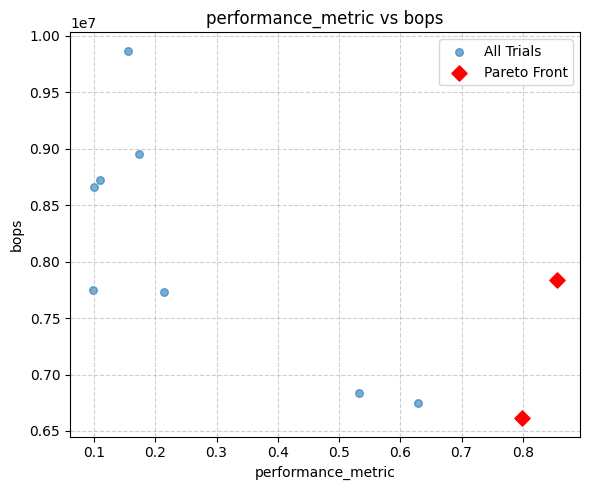


Global search plots saved to: ./results/Newhybrid_search_tutorial


In [4]:
print("\n" + "="*50)
print("ANALYZING GLOBAL SEARCH RESULTS")
print("="*50)

results_df_hybrid = pd.DataFrame(searcher_simple.results)

if not results_df_hybrid.empty:
    print("\n--- Generating Pareto Front Plots for Global Search ---")
    plot_pareto_fronts(results_df_hybrid, OBJECTIVE_INFO_HYBRID, save_dir=searcher_simple.results_dir)
    print(f"\nGlobal search plots saved to: {searcher_simple.results_dir}")
else:
    print("Global search did not yield any results to analyze.")


In [11]:
# ## Part 2: Automated Local Search (QAT + Pruning)
# 
# Now, we take the `best_model_for_local_search.yaml` file that was automatically generated by the global search and run it through the local search pipeline.

# %%
# --- Configuration for Local Search ---
LOCAL_SEARCH_RESULTS_DIR = "./results/local_search_tutorial"
LOCAL_SEARCH_CONFIG_PATH = 'local_search_settings.yaml'

# Define the settings for the local search (precisions, pruning, etc.)
local_search_settings = {
    'precision_pairs': [
        {'total_bits': 16, 'int_bits': 6},
        {'total_bits': 8, 'int_bits': 3},
    ],
    # 'precision_pairs': [
    #     {'total_bits': 16, 'int_bits': 6},
    #     {'total_bits': 8, 'int_bits': 3},
    #     {'total_bits': 4, 'int_bits': 1},
    # ],
    'pruning_iterations': 3,
    'epochs_per_iteration': 5,
    'pruning_rate': 0.8, # Prune 20% of remaining weights each iteration (1 - 0.8)
}

# Write the settings to a YAML file
with open(LOCAL_SEARCH_CONFIG_PATH, 'w') as f:
    yaml.dump(local_search_settings, f)
print(f"Created local search configuration file: {LOCAL_SEARCH_CONFIG_PATH}")

# Path to the best model found by the global search
ARCHITECTURE_YAML_PATH = os.path.join(RESULTS_DIR_HYBRID, "best_model_for_local_search.yaml")

# --- Load Dataset for Local Search ---
# Ensure we use the same data preprocessing as the global search
resize_val = searcher_simple.search_space.get('initial_img_size', 11)
x_train, y_train, x_val, y_val = load_and_preprocess_mnist(
    resize_val=resize_val, 
    subset_size=SUBSET_SIZE_HYBRID, 
    flatten=False,
    one_hot=False
)


Created local search configuration file: local_search_settings.yaml
Data loaded and preprocessed:
  Resize: 11x11
  x_train shape: (40000, 11, 11, 1), x_val shape: (10000, 11, 11, 1)
  y_train shape: (40000,), y_val shape: (10000,)


In [12]:
if os.path.exists(ARCHITECTURE_YAML_PATH):
    local_search_df = local_search_entrypoint(
        architecture_yaml_path=ARCHITECTURE_YAML_PATH,
        local_search_config_path=LOCAL_SEARCH_CONFIG_PATH,
        dataset=(x_train, y_train, x_val, y_val),
        results_dir=LOCAL_SEARCH_RESULTS_DIR
    )
else:
    print(f"ERROR: Could not find the architecture file: {ARCHITECTURE_YAML_PATH}")
    print("Please ensure the global search ran successfully.")
    local_search_df = pd.DataFrame()




 STARTING LOCAL SEARCH STAGE 
--- Loading model architecture from: ./results/Newhybrid_search_tutorial/best_model_for_local_search.yaml ---
--- Model successfully reconstructed ---
Model: "BlockArchitecture"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_14 (InputLayer)       [(None, 11, 11, 1)]       0         
                                                                 
 initial_flatten (Flatten)   (None, 121)               0         
                                                                 
 mlp_block_0 (Sequential)    (None, 33)                4026      
                                                                 
 mlp_block_3 (Sequential)    (None, 34)                1156      
                                                                 
 classifier_head (Sequentia  (None, 10)                2617      
 l)                                                              


--- Pruning Iteration 1/3 | Target Sparsity: 0.2000 ---
Epoch 1/5
313/313 [==============================] - 3s 3ms/step - loss: 1.9601 - accuracy: 0.3952 - val_loss: 1.5142 - val_accuracy: 0.4925
Epoch 2/5
313/313 [==============================] - 1s 2ms/step - loss: 1.3370 - accuracy: 0.6059 - val_loss: 1.1264 - val_accuracy: 0.7110
Epoch 3/5
313/313 [==============================] - 1s 2ms/step - loss: 1.2132 - accuracy: 0.6429 - val_loss: 1.6974 - val_accuracy: 0.3991
Epoch 4/5
313/313 [==============================] - 1s 2ms/step - loss: 1.0892 - accuracy: 0.6698 - val_loss: 1.0137 - val_accuracy: 0.7218
Epoch 5/5
313/313 [==============================] - 1s 2ms/step - loss: 0.8868 - accuracy: 0.7911 - val_loss: 0.8020 - val_accuracy: 0.8201
Iteration 1 Accuracy: 0.8201
--> New best accuracy for this precision: 0.8201

--- Pruning Iteration 2/3 | Target Sparsity: 0.3600 ---
Epoch 1/5
313/313 [==============================] - 3s 3ms/step - loss: 1.6674 - accuracy: 0.5045 - va

/home/users/ddemler/miniconda3/envs/my_docker_env/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/5
313/313 [==============================] - 3s 2ms/step - loss: 1.8419 - accuracy: 0.4563 - val_loss: 1.2676 - val_accuracy: 0.6811
Epoch 2/5
313/313 [==============================] - 1s 2ms/step - loss: 1.2753 - accuracy: 0.6451 - val_loss: 1.1309 - val_accuracy: 0.6801
Epoch 3/5
313/313 [==============================] - 1s 2ms/step - loss: 1.0734 - accuracy: 0.7088 - val_loss: 0.9515 - val_accuracy: 0.7783
Epoch 4/5
313/313 [==============================] - 1s 2ms/step - loss: 1.1352 - accuracy: 0.6328 - val_loss: 0.9804 - val_accuracy: 0.7808
Epoch 5/5
313/313 [==============================] - 1s 2ms/step - loss: 0.9324 - accuracy: 0.7843 - val_loss: 0.8862 - val_accuracy: 0.8056
Iteration 1 Accuracy: 0.8056
--> New best accuracy for this precision: 0.8056

--- Pruning Iteration 2/3 | Target Sparsity: 0.3600 ---
Epoch 1/5
313/313 [==============================] - 3s 3ms/step - loss: 1.5080 - accuracy: 0.5442 - val_loss: 1.1232 - val_accuracy: 0.7228
Epoch 2/5
313/313 [